# <center> ИССЛЕДОВАНИЕ ДАННЫХ HR-АГЕНТСТВА

## Постановка задачи

HR-агентство изучает тренды на рынке труда в IT. Компания хочет провести исследование на основе данных о зарплатах в сфере Data Science за 2020–2022 годы и получить некоторые выводы.

Оригинальный датасет: “Data Science Job Salaries” (kaggle.com)

Исследуйте данные и сделайте выводы по полученным результатам. Подкрепите свои рассуждения и выводы визуализациями и с помощью статистического тестирования проверьте, являются ли выводы статистически значимыми.

В процессе своего анализа вы должны:

*   Выяснить, какие факторы влияют на зарплату специалиста Data Scientist.
*   А также ответить на ключевые вопросы HR-агентства:
        *   Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?
        *   Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?
        *   Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?
        *   Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?

*   Если вы найдёте в данных интересные закономерности, также отметьте их в своём анализе.

*   Продемонстрируйте использование разных тестов для проверки статистической значимости сделанных выводов.

Ответить на эти вопросы нам помогут следующие данные:
*   *work_year* —  	год, в котором была выплачена зарплата;
*   *experience_level* — опыт работы на этой должности в течение года;
*   *employment_type* — тип трудоустройства для этой роли;
*   *job_title* — роль, в которой соискатель работал в течение года;
*   *salary* — общая выплаченная валовая сумма заработной платы;
*   *salary_currency* — валюта выплачиваемой заработной платы в виде кода валюты ISO 4217.;
*   *salary_in_usd* — зарплата в долларах США;
*   *employee_residence* — основная страна проживания сотрудника в течение рабочего года в виде кода страны ISO 3166;
*   *remote_ratio* — общий объём работы, выполняемой удалённо;
*   *company_location* — страна главного офиса работодателя или филиала по контракту в виде кода страны ISO 3166;
*   *company_size* — среднее количество людей, работавших в компании в течение года.

## Загрузка данных

In [193]:
# загружаем необходимые библиотеки
import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
from statsmodels import stats as sms

import matplotlib.pyplot as plt
import seaborn as sns

# делаем визуальную настройку графиков
sns.set_theme("notebook") 
sns.set_palette("Set2") 

In [194]:
# загружаем датасет
data = pd.read_csv('./ds_salaries.csv')
data.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [195]:
# задаём уровень значимости
alpha = 0.05 
print("Уровень значимости alpha = {:.2f}".format(alpha))

Уровень значимости alpha = 0.05


## Описательный анализ данных

In [196]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


В датасете 607 записей (без пропущенных значений).

Проверим данные на наличие полных дубликатов:

In [197]:
print('Количество дубликатов: {}'.format(data[data.duplicated()].shape[0]))

# Удаляем дубликаты:
data = data.drop_duplicates()
print('Размер таблицы после удаления дубликатов: {}'.format(data.shape))

Количество дубликатов: 0
Размер таблицы после удаления дубликатов: (607, 12)


### Зависимость зарплат от различных факторов

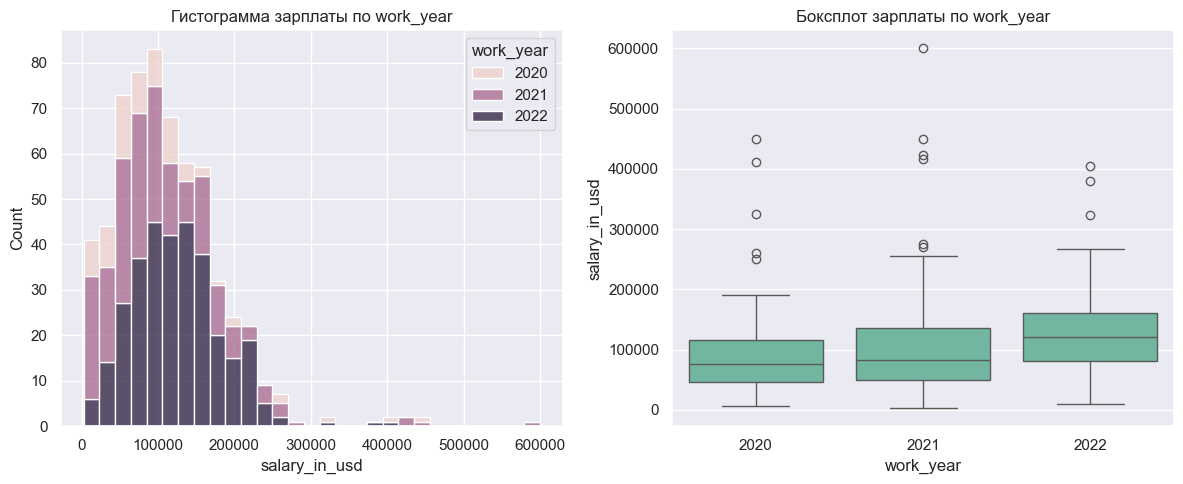

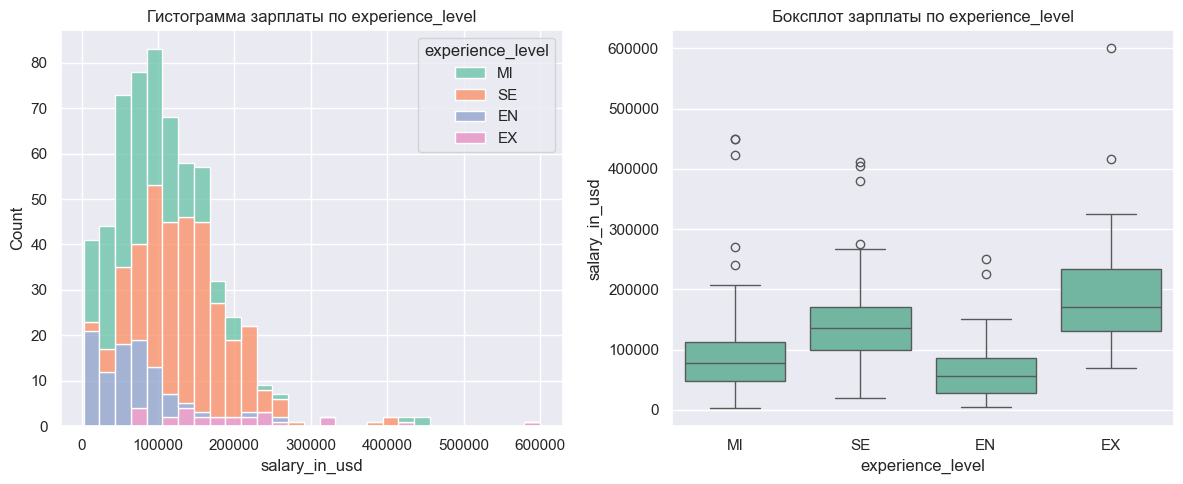

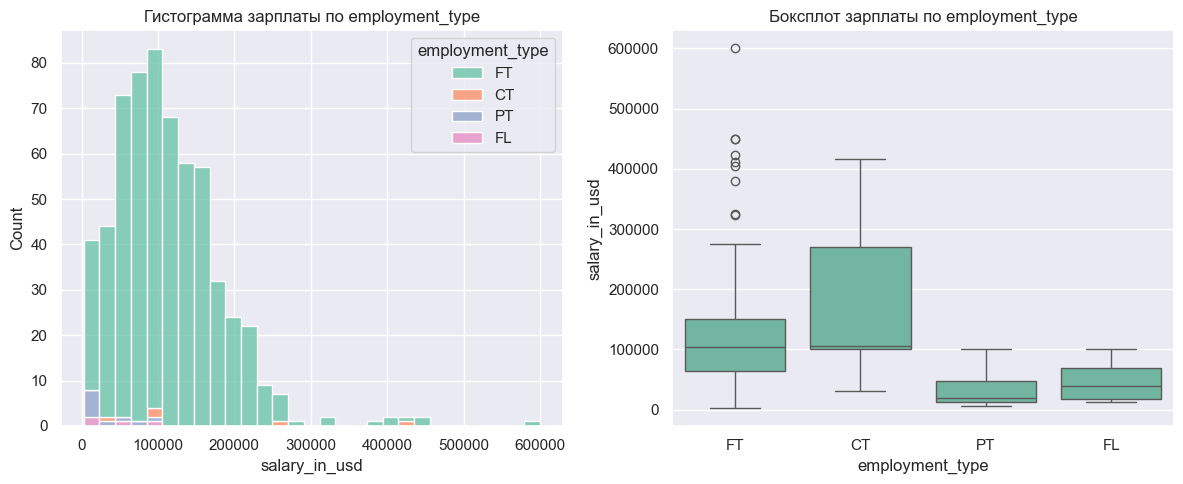

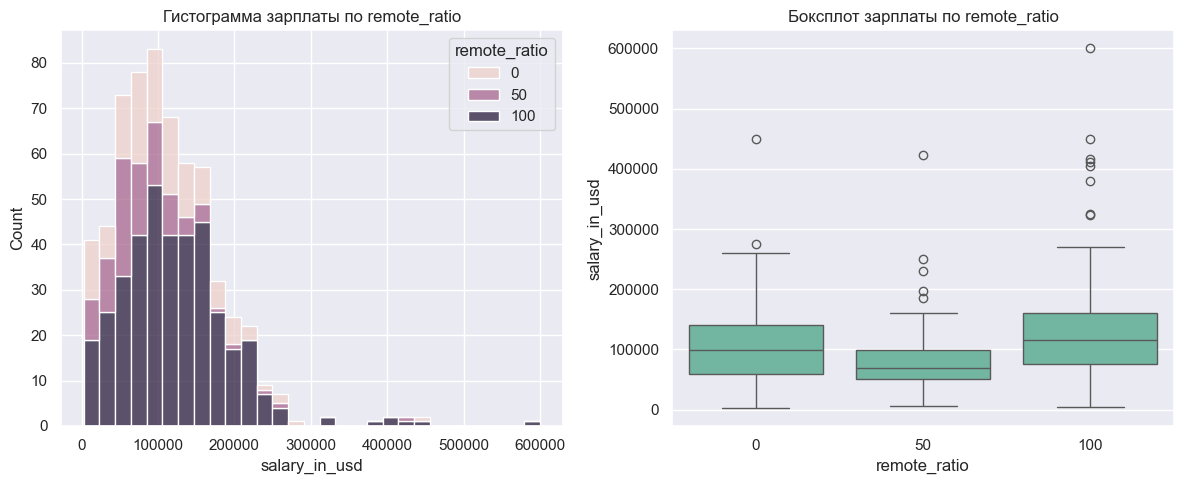

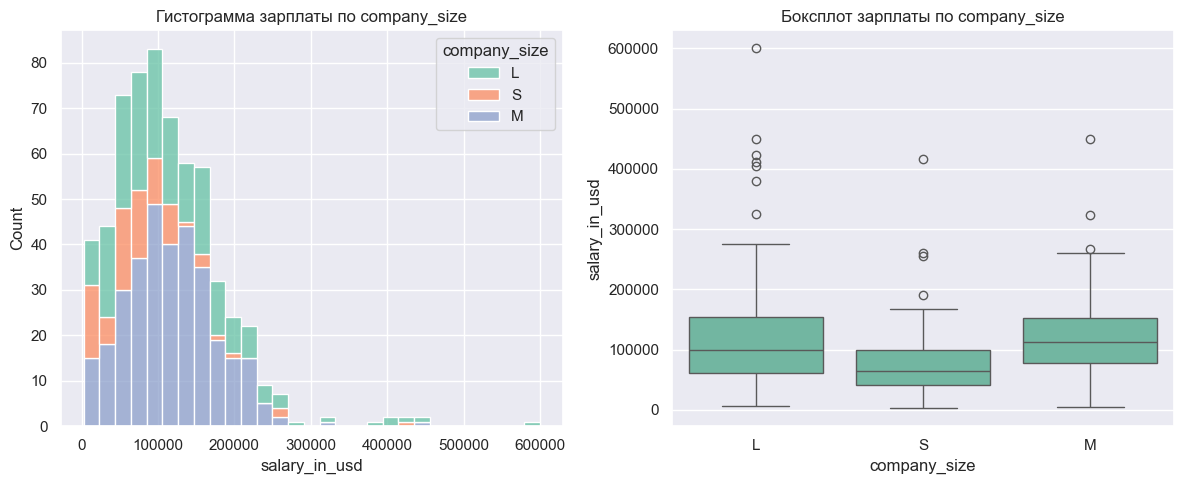

In [198]:
factors = ['work_year', 'experience_level', 'employment_type', 'remote_ratio', 'company_size']

for factor in factors:
    plt.figure(figsize=(12, 5))
    
    # Гистограмма зарплат по фактору
    plt.subplot(1, 2, 1)
    sns.histplot(data=data, x='salary_in_usd', hue=factor, multiple='stack', kde=False)
    plt.title(f'Гистограмма зарплаты по {factor}')
    
    # Боксплот зарплат по фактору
    plt.subplot(1, 2, 2)
    sns.boxplot(x=factor, y='salary_in_usd', data=data)
    plt.title(f'Боксплот зарплаты по {factor}')
    
    plt.tight_layout()
    plt.show()

In [199]:
factors = ['work_year', 'experience_level', 'employment_type', 'remote_ratio', 'company_size']

for factor in factors:
    summary = data.groupby(factor)['salary_in_usd'].agg(['mean', 'median', 'count']).reset_index()
    summary.rename(columns={'mean': 'Средняя зарплата (USD)', 'median': 'Медианная зарплата (USD)', 'count': 'Кол-во записей'}, inplace=True)
    print(f"Статистика для фактора: {factor}")
    print(summary)
    print("\n")

Статистика для фактора: work_year
   work_year  Средняя зарплата (USD)  Медианная зарплата (USD)  Кол-во записей
0       2020            95813.000000                   75544.0              72
1       2021            99853.792627                   82528.0             217
2       2022           124522.006289                  120000.0             318


Статистика для фактора: experience_level
  experience_level  Средняя зарплата (USD)  Медианная зарплата (USD)  \
0               EN            61643.318182                   56500.0   
1               EX           199392.038462                  171437.5   
2               MI            87996.056338                   76940.0   
3               SE           138617.292857                  135500.0   

   Кол-во записей  
0              88  
1              26  
2             213  
3             280  


Статистика для фактора: employment_type
  employment_type  Средняя зарплата (USD)  Медианная зарплата (USD)  \
0              CT           18457

По гистограммам и боксплотам зарплат специалистов Data Scientist по различным факторам можно сделать следующие общие выводы:

*   Опыт работы (experience_level) сильно влияет на зарплату — с ростом уровня опыта средняя зарплата значительно увеличивается, при этом разброс зарплат у экспертов (SE, EX) больше.

*   Тип занятости (employment_type) показывает, что полный рабочий день даёт более высокую и стабильную зарплату, в то время как контракт и фриланс имеют более широкий разброс с более низкими медианами.

*   Уровень удалённой работы (remote_ratio) может влиять — специалисты с полностью удалённой работой (100) часто имеют либо более высокие, либо более разнообразные зарплаты по сравнению с офисной работой.

*   Размер компании (company_size) также коррелирует с зарплатой: крупные компании (L) чаще платят больше, средние (M) и малые (S) — меньше, с большим разбросом.

*   Год выплаты (work_year) показывает тренд роста зарплат с годами.

### Средняя зарплата Data Scientist по годам

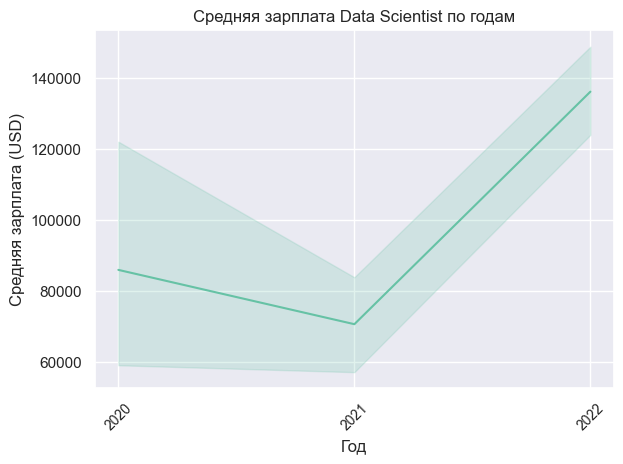

In [200]:
sns.lineplot(
    x='work_year', 
    y='salary_in_usd', 
    data=data[data['job_title'] == 'Data Scientist'],  # фильтрация здесь
    estimator='mean', 
    errorbar=('ci', 95)
)

plt.title('Средняя зарплата Data Scientist по годам')
plt.xlabel('Год')
plt.ylabel('Средняя зарплата (USD)')

unique_years = sorted(data['work_year'].unique())
plt.xticks(ticks=unique_years, labels=unique_years, rotation=45, fontsize=10)

plt.tight_layout()
plt.show()


Средняя зарплата Data Scientist была около $85,000 в 2020 году и стала почти $140,000 в 2022 году.

### Распределение зарплат Data Scientist по странам

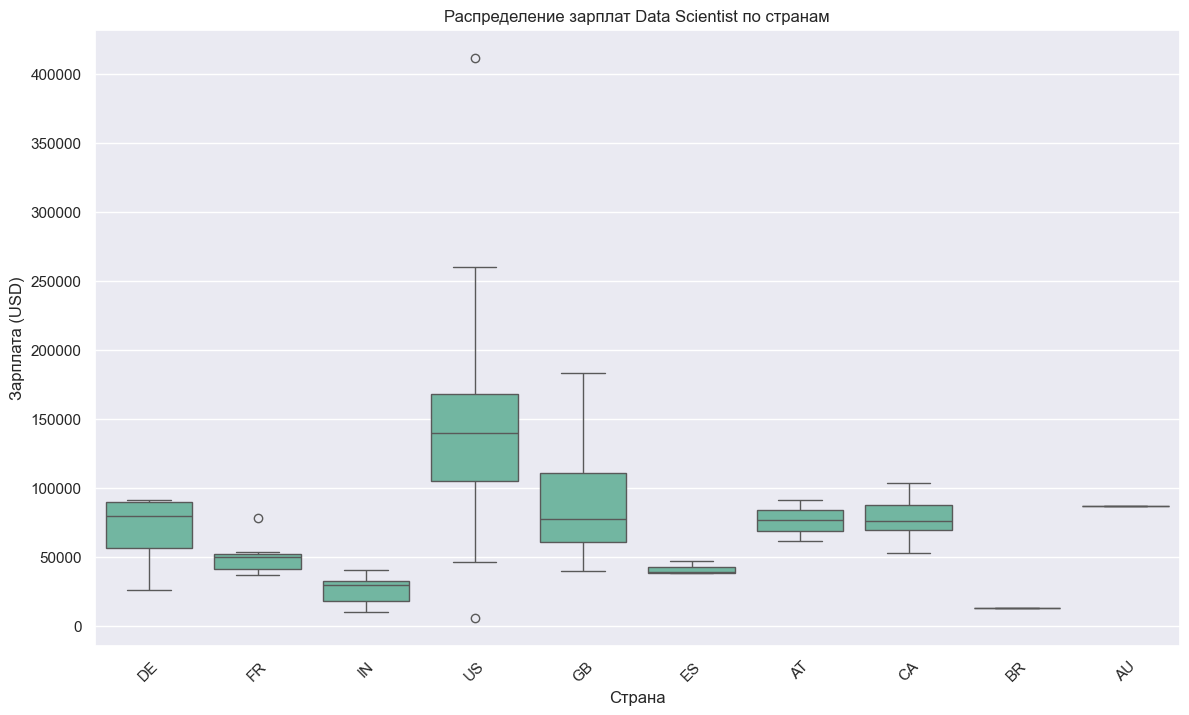

In [201]:
top_cities = data[data['job_title'] == 'Data Scientist']['company_location'].value_counts().nlargest(10).index

plt.figure(figsize=(14, 8))
sns.boxplot(
    x='company_location', 
    y='salary_in_usd', 
    data=data[(data['company_location'].isin(top_cities)) & (data['job_title'] == 'Data Scientist')]
)
plt.title('Распределение зарплат Data Scientist по странам')
plt.xlabel('Страна')
plt.ylabel('Зарплата (USD)')
plt.xticks(rotation=45)
plt.show()

Зарплаты существенно отличаются в зависимости от стран компаний, что может быть связано с уровнем экономического развития. Наибольний уровень зарплат наблюдается в компаниях в США.

### Сравнение зарплат Data Scientist и Data Engineer в 2022 году

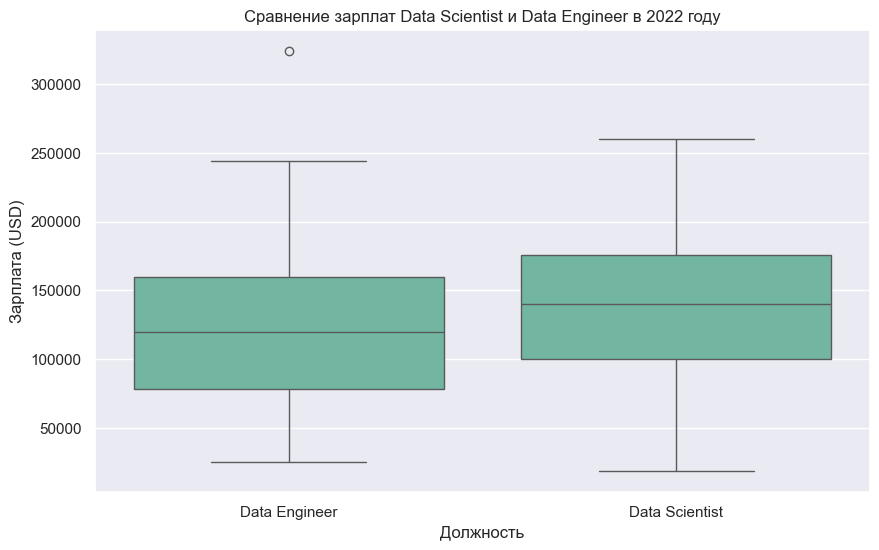

In [202]:
# Фильтруем данные за 2022 год и по должностям Data Scientist и Data Engineer
filtered_data = data[(data['work_year'] == 2022) & (data['job_title'].isin(['Data Scientist', 'Data Engineer']))]

plt.figure(figsize=(10, 6))
sns.boxplot(x='job_title', y='salary_in_usd', data=filtered_data)
plt.title('Сравнение зарплат Data Scientist и Data Engineer в 2022 году')
plt.xlabel('Должность')
plt.ylabel('Зарплата (USD)')
plt.show()


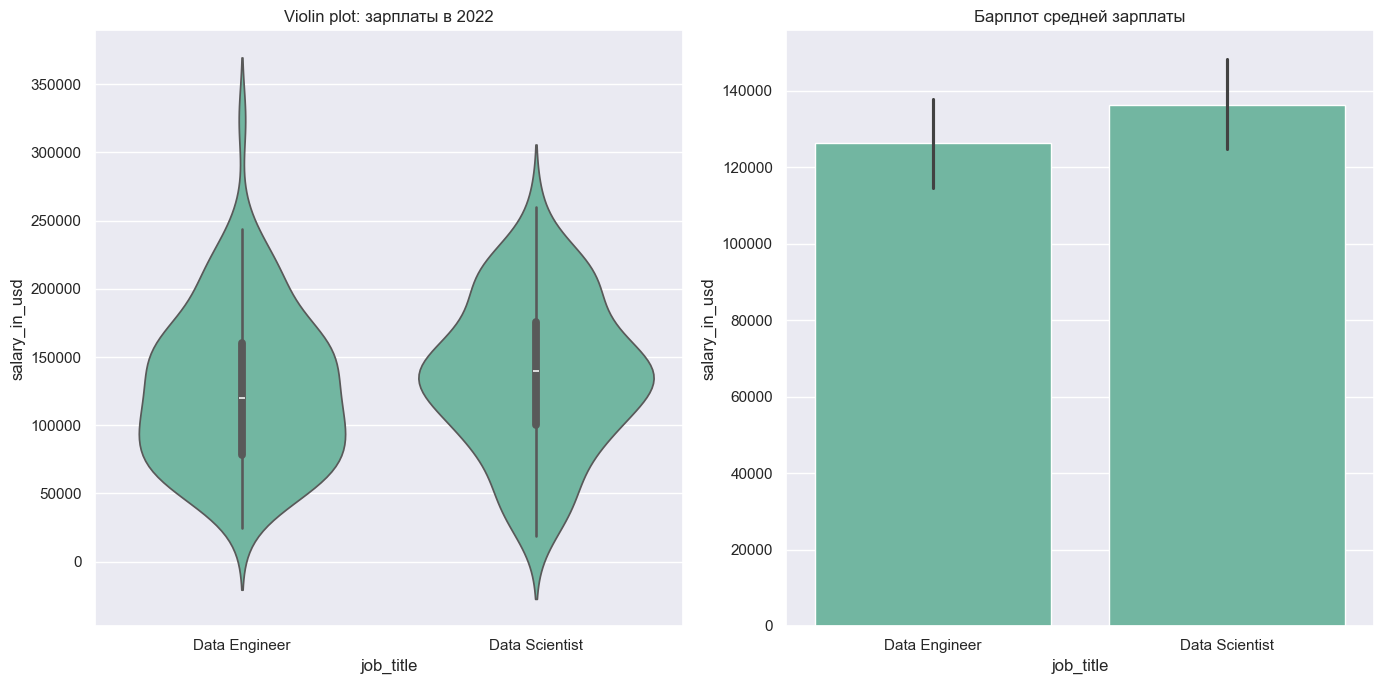

In [203]:
filtered_data = data[(data['work_year'] == 2022) & (data['job_title'].isin(['Data Scientist', 'Data Engineer']))]

plt.figure(figsize=(14, 7))

# Violin plot
plt.subplot(1, 2, 1)
sns.violinplot(x='job_title', y='salary_in_usd', data=filtered_data)
plt.title('Violin plot: зарплаты в 2022')

# Bar plot с доверительным интервалом
plt.subplot(1, 2, 2)
sns.barplot(x='job_title', y='salary_in_usd', data=filtered_data, errorbar=('ci', 95))
plt.title('Барплот средней зарплаты')

plt.tight_layout()
plt.show()


In [204]:
summary = data[data['job_title'].isin(['Data Scientist', 'Data Engineer'])].groupby('job_title')['salary_in_usd'].agg(['mean', 'median', 'min', 'max', 'count']).reset_index()
summary.rename(columns={'mean': 'Средняя зарплата (USD)', 'median': 'Медианная зарплата (USD)', 'min': 'Мин. зарплата (USD)', 'max': 'Макс. зарплата (USD)', 'count': 'Кол-во записей'}, inplace=True)
print(summary)

        job_title  Средняя зарплата (USD)  Медианная зарплата (USD)  \
0   Data Engineer           112725.000000                  105500.0   
1  Data Scientist           108187.832168                  103691.0   

   Мин. зарплата (USD)  Макс. зарплата (USD)  Кол-во записей  
0                 4000                324000             132  
1                 2859                412000             143  


В среднем зарплаты Data Scientist и Data Engineer находятся на близком уровне, с возможными вариациями в зависимости от компании и страны. 

Проверим статистическую разницу:

In [205]:
from scipy.stats import shapiro

# Данные для Data Scientist
ds_data = data[data['job_title'] == 'Data Scientist']['salary_in_usd']
stat_ds, p_ds = shapiro(ds_data)
print(f'Data Scientist: Statistic={stat_ds:.3f}, p-value={p_ds:.3f}')
if p_ds > 0.05:
    print("Данные Data Scientist распределены нормально")
else:
    print("Данные Data Scientist не распределены нормально")

# Данные для Data Engineer
de_data = data[data['job_title'] == 'Data Engineer']['salary_in_usd']
stat_de, p_de = shapiro(de_data)
print(f'Data Engineer: Statistic={stat_de:.3f}, p-value={p_de:.3f}')
if p_de > 0.05:
    print("Данные Data Engineer распределены нормально")
else:
    print("Данные Data Engineer не распределены нормально")

from scipy.stats import mannwhitneyu

# Выбираем данные по зарплатам двух групп
ds_salaries = data[data['job_title'] == 'Data Scientist']['salary_in_usd']
de_salaries = data[data['job_title'] == 'Data Engineer']['salary_in_usd']

# Выполняем тест Манна-Уитни, двусторонняя альтернатива
stat, p_value = mannwhitneyu(ds_salaries, de_salaries, alternative='two-sided')

print(f'Mann-Whitney U statistic: {stat}')
print(f'P-value: {p_value}')

if p_value < 0.05:
    print("Статистически значимая разница в зарплатах между Data Scientist и Data Engineer")
else:
    print("Статистически значимой разницы в зарплатах между Data Scientist и Data Engineer нет")



Data Scientist: Statistic=0.948, p-value=0.000
Данные Data Scientist не распределены нормально
Data Engineer: Statistic=0.973, p-value=0.010
Данные Data Engineer не распределены нормально
Mann-Whitney U statistic: 8958.5
P-value: 0.46722185067886324
Статистически значимой разницы в зарплатах между Data Scientist и Data Engineer нет


### Распределение зарплат Data Scientist по размерам компаний

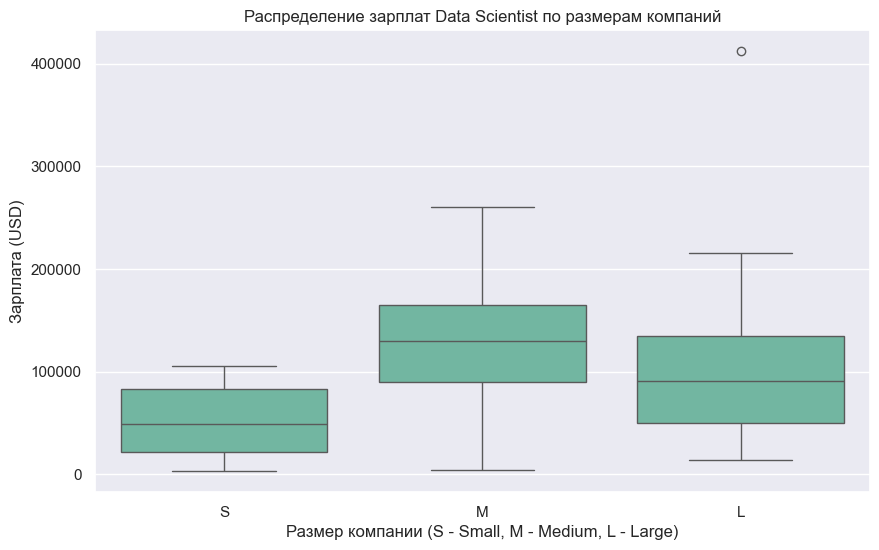

In [206]:
import seaborn as sns
import matplotlib.pyplot as plt

# Фильтр по Data Scientist
ds_data = data[data['job_title'] == 'Data Scientist']

plt.figure(figsize=(10, 6))
sns.boxplot(x='company_size', y='salary_in_usd', data=ds_data, order=['S', 'M', 'L'])
plt.title('Распределение зарплат Data Scientist по размерам компаний')
plt.xlabel('Размер компании (S - Small, M - Medium, L - Large)')
plt.ylabel('Зарплата (USD)')
plt.show()


In [207]:
ds_data = data[data['job_title'] == 'Data Scientist']
summary = ds_data.groupby('company_size')['salary_in_usd'].agg(['mean', 'median', 'min', 'max', 'count']).reset_index()
summary.rename(columns={
    'mean': 'Средняя зарплата (USD)',
    'median': 'Медианная зарплата (USD)',
    'min': 'Мин. зарплата (USD)',
    'max': 'Макс. зарплата (USD)',
    'count': 'Кол-во записей'
}, inplace=True)
print(summary)


  company_size  Средняя зарплата (USD)  Медианная зарплата (USD)  \
0            L           103313.355556                   90734.0   
1            M           126380.753247                  130000.0   
2            S            51925.761905                   49268.0   

   Мин. зарплата (USD)  Макс. зарплата (USD)  Кол-во записей  
0                13400                412000              45  
1                 4000                260000              77  
2                 2859                105000              21  


В компаниях среднего размера могут платить больше. Проверим насколько статистически значима разница с большими компаниями.

In [208]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu

# Выборки для средних (M) и больших (L) компаний
salary_M = data[(data['job_title'] == 'Data Scientist') & (data['company_size'] == 'M')]['salary_in_usd']
salary_L = data[(data['job_title'] == 'Data Scientist') & (data['company_size'] == 'L')]['salary_in_usd']

# Проверка нормальности
p_M = shapiro(salary_M).pvalue
p_L = shapiro(salary_L).pvalue

print(f'p-value нормальности (Medium): {p_M:.3f}')
print(f'p-value нормальности (Large): {p_L:.3f}')

alpha = 0.05

if p_M > alpha and p_L > alpha:
    # Нормальные данные — t-тест
    stat, p = ttest_ind(salary_M, salary_L)
    test_name = "t-тест Стьюдента"
else:
    # Ненормальные — тест Манна-Уитни
    stat, p = mannwhitneyu(salary_M, salary_L)
    test_name = "тест Манна-Уитни"

print(f"{test_name}: статистика={stat:.3f}, p-значение={p:.3f}")

if p < alpha:
    print("Разница в зарплатах средних и больших компаний статистически значима")
else:
    print("Статистически значимой разницы в зарплатах нет")


p-value нормальности (Medium): 0.639
p-value нормальности (Large): 0.000
тест Манна-Уитни: статистика=2209.500, p-значение=0.011
Разница в зарплатах средних и больших компаний статистически значима


### Распределение Data Scientist и Data Engineer по размерам компаний

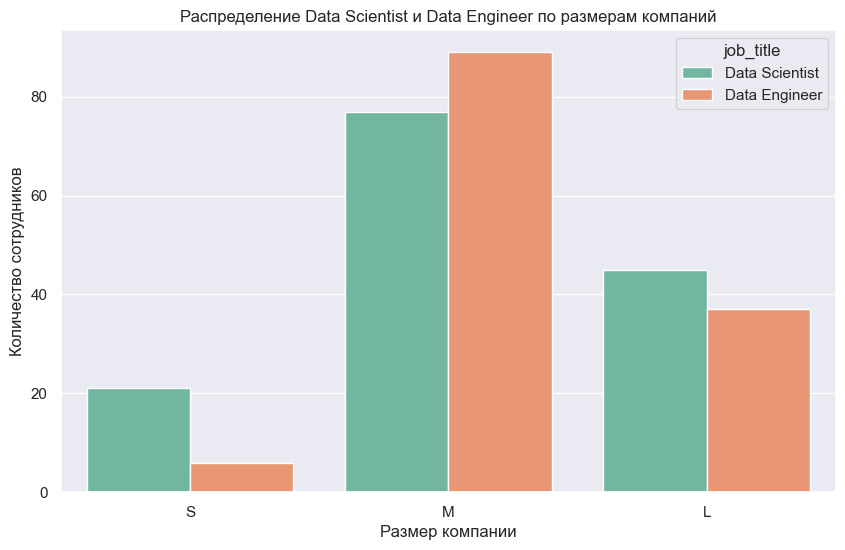

In [209]:
filtered = data[data['job_title'].isin(['Data Scientist', 'Data Engineer'])]

plt.figure(figsize=(10,6))
sns.countplot(x='company_size', hue='job_title', data=filtered, order=['S', 'M', 'L'])
plt.title('Распределение Data Scientist и Data Engineer по размерам компаний')
plt.xlabel('Размер компании')
plt.ylabel('Количество сотрудников')
plt.show()


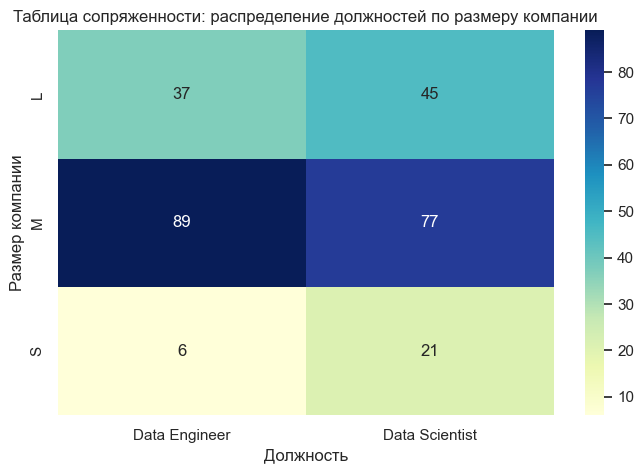

In [210]:
# Создаем таблицу сопряженности
filtered = data[data['job_title'].isin(['Data Scientist', 'Data Engineer'])]
contingency_table = pd.crosstab(filtered['company_size'], filtered['job_title'])

# Визуализируем тепловую карту
plt.figure(figsize=(8, 5))
sns.heatmap(contingency_table, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Таблица сопряженности: распределение должностей по размеру компании')
plt.xlabel('Должность')
plt.ylabel('Размер компании')
plt.show()


Можно сделать следующие выводы:

*   В компаниях среднего размера (M) количество Data Engineer (89) и Data Scientist (77) значительно выше, чем в маленьких (S) и больших (L) компаниях.

*   Маленькие компании (S) существенно реже нанимают Data Engineer, но имеют относительно больше Data Scientist по сравнению с Data Engineer.

*   В больших компаниях (L) доля Data Scientist немного выше, чем Data Engineer, однако и там количество специалистов ниже, чем в компаниях среднего размера.

*   Это может свидетельствовать о том, что средние компании активнее развивают и расширяют команды Data Engineer и Data Scientist, возможно, из-за масштабирования инфраструктуры и аналитики.

*   Маленькие компании могут концентрироваться на более универсальных Data Scientist, выполняющих более широкий спектр задач без необходимости отдельного инженера.

## Статистический анализ данных



In [211]:
# функция для принятия решения о нормальности
def decision_normality(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Распределение отлично от нормального'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. Распределение является нормальным'.format(alpha))


# функция для принятия решения об отклонении нулевой гипотезы
def decision_hypothesis(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу в пользу альтернативной.'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))
      

### Общий объём работы, выполняемой удалённо Data Scientist, влияет или нет на уровень зарплаты Data Scientist?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): Общий объём работы, выполняемой удалённо Data Scientist ($μ_1$) не оказывает значимого влияния на уровень зарплаты Data Scientist ($μ_2$).

$$ H_0 : μ_1 <= μ_2$$

*Альтернативная гипотеза* ($H_1$): Общий объём работы, выполняемой удалённо Data Scientist ($μ_1$) влияет на уровень зарплаты Data Scientist ($μ_2$).

$$ H_1 : μ_1 > μ_2$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально. Напомним гипотезы теста Шапиро-Уилка:

*Нулевая гипотеза* ($H_0$): распределение данные является нормальным.

*Альтернативная гипотеза* ($H_1$): распределение данных отлично от нормального.

In [212]:

data_sample = data['remote_ratio']

stat, p_value = shapiro(data_sample)

print(f'Статистика теста: {stat:.3f}')
print(f'p-value: {p_value:.3f}')

if p_value > alpha:
    print("Принимаем нулевую гипотезу H0: распределение нормально")
else:
    print("Отклоняем нулевую гипотезу H0: данные распределены не нормально")


Статистика теста: 0.670
p-value: 0.000
Отклоняем нулевую гипотезу H0: данные распределены не нормально


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Общий объём работы, выполняемой удалённо»? — Количественный.
* Сколько сравниваемых групп? — Три.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет.

Чтобы проверить нашу гипотезу, можно использовать критерий Крускала-Уоллиса для сравнения распределений на основе рангов.

**Проведём тест**

In [213]:
from scipy.stats import kruskal

ds_data = data[data['job_title'] == 'Data Scientist']

group_0 = ds_data[ds_data['remote_ratio'] == 0]['salary_in_usd']
group_50 = ds_data[ds_data['remote_ratio'] == 50]['salary_in_usd']
group_100 = ds_data[ds_data['remote_ratio'] == 100]['salary_in_usd']


# Для сравнения всех трех групп — критерий Крускала-Уоллиса
stat_all, p_all = kruskal(group_0, group_50, group_100)
print(f'Kruskal-Wallis test for all groups: statistic={stat_all}, p-value={p_all}')

if p_all < alpha:
    print("Есть статистически значимые различия в зарплатах по объёму удалённой работы")
else:
    print("Статистически значимых различий в зарплатах по объёму удалённой работы нет")


Kruskal-Wallis test for all groups: statistic=12.192103734399288, p-value=0.00225174036275755
Есть статистически значимые различия в зарплатах по объёму удалённой работы


**Вывод**

Есть основания утверждать, что объём удалённой работы влияет на уровень зарплаты Data Scientist.

### Распределение зарплат Data Scientist одинаково и в 2020, и в 2022 году?


**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): распределение зарплат Data Scientist ($μ_1$) одинаково и в 2020, и в 2022 году ($μ_2$).

$$ H_0 : μ_1 >= μ_2$$

*Альтернативная гипотеза* ($H_1$): распределение зарплат Data Scientist ($μ_1$) различается и в 2020, и в 2022 году ($μ_2$).
$$ H_1 : μ_1 < μ_2$$




**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [214]:
ds_salaries = data[data['job_title'] == 'Data Scientist']['salary_in_usd']

stat, p_value = shapiro(ds_salaries)

print(f"Статистика: {stat:.3f}")
print(f"p-значение: {p_value:.3f}")

if p_value > alpha:
    print("Распределение зарплат Data Scientist можно считать нормальным")
else:
    print("Распределение зарплат Data Scientist не является нормальным")

Статистика: 0.948
p-значение: 0.000
Распределение зарплат Data Scientist не является нормальным


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Зарплата Data Scientist»? — Количественный.
* Сколько сравниваемых групп? — Две.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет.

Для проверки нашей гипотезы можно использовать U-критерий Манна-Уитни.

**Проведём тест**


In [215]:
# проводим тест
from scipy.stats import mannwhitneyu

salaries_2020 = data[(data['job_title'] == 'Data Scientist') & (data['work_year'] == 2020)]['salary_in_usd']
salaries_2022 = data[(data['job_title'] == 'Data Scientist') & (data['work_year'] == 2022)]['salary_in_usd']

stat, p_value = mannwhitneyu(salaries_2020, salaries_2022, alternative='two-sided')

print(f'U-статистика: {stat}')
print(f'p-значение: {p_value:.10f}')

if p_value < alpha:
    print("Есть статистически значимая разница в распределении зарплат в 2020 и 2022 годах")
else:
    print("Нет статистически значимой разницы в распределении зарплат в 2020 и 2022 годах")


U-статистика: 315.0
p-значение: 0.0000196019
Есть статистически значимая разница в распределении зарплат в 2020 и 2022 годах


**Вывод**

Произошли изменения в уровне или распределении зарплат специалистов Data Scientist между 2020 и 2022 годами, которые нельзя объяснить случайностью.​

### Отличается ли существенно размер зарплат Data Scientist в США и Великобритании?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза*: размер заработной платы Зарплаты Data Scientist не отличается в США ($μ_1$) и Великобритании ($μ_2$).

$$ H_0 : μ_1 = μ_2$$

*Альтернативная гипотеза*: размер заработной платы Зарплаты Data Scientist отличается в США ($μ_1$) и Великобритании ($μ_2$).

$$ H_1 : μ_1 \neq μ_2 $$



**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [216]:
salaries_us = data[(data['job_title'] == 'Data Scientist') & (data['employee_residence'] == 'US')]['salary']

salaries_gb = data[(data['job_title'] == 'Data Scientist') & (data['employee_residence'] == 'GB')]['salary']

# Тест Шапиро-Уилка для США
stat_us, p_us = shapiro(salaries_us)
print(f"USA: Статистика={stat_us:.3f}, p-value={p_us:.3f}")
if p_us > 0.05:
    print("Для США распределение нормальное")
else:
    print("Для США распределение не нормальное")

# Тест Шапиро-Уилка для Великобритании
stat_gb, p_gb = shapiro(salaries_gb)
print(f"GB: Статистика={stat_gb:.3f}, p-value={p_gb:.3f}")
if p_gb > 0.05:
    print("Для Великобритании распределение нормальное")
else:
    print("Для Великобритании распределение не нормальное")    

USA: Статистика=0.884, p-value=0.000
Для США распределение не нормальное
GB: Статистика=0.913, p-value=0.264
Для Великобритании распределение нормальное


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Зарплата Data Scientist»? — Количественный.
* Сколько сравниваемых групп? — Две.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет. 

Для проверки нашей гипотезы можно использовать U-критерий Манна-Уитни.

**Проведём тест**

In [217]:
# проводим тест

salaries_us = data[(data['job_title'] == 'Data Scientist') & (data['employee_residence'] == 'US')]['salary']
salaries_gb = data[(data['job_title'] == 'Data Scientist') & (data['employee_residence'] == 'GB')]['salary']

stat, p_value = mannwhitneyu(salaries_us, salaries_gb, alternative='two-sided')

print(f'U-статистика: {stat}')
print(f'p-значение: {p_value:.6f}')

if p_value < alpha:
    print("Отвергаем нулевую гипотезу: различия в зарплатах между США и Великобританией статистически значимы")
else:
    print("Нет оснований отвергать нулевую гипотезу: статистически значимых различий в зарплатах нет")


U-статистика: 802.0
p-значение: 0.000003
Отвергаем нулевую гипотезу: различия в зарплатах между США и Великобританией статистически значимы


**Вывод**

Есть основания утверждать, что различия в зарплатах между США и Великобританией статистически значимы.

### Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза*: Должности Data Scientist и Data Engineer не связаны с размером компании (признаки независимы).

*Альтернативная гипотеза*: Должности Data Scientist и Data Engineer связаны с размером компании (признаки зависимы).


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака "Наличие должностей Data Scientist и Data Engineer" — категориальный признак двух уровней (присутствует/отсутствует).
* Сколько сравниваемых групп? — две группы (Data Scientist, Data Engineer).
* Проверяется независимость групп? — Да.

Для проверки нашей гипотезы можно использовать критерий ${\chi}^2$ (хи-квадрат).

**Проведём тест**

In [218]:
# проводим тест
from scipy.stats import chi2_contingency

data['is_DS_or_DE'] = data['job_title'].isin(['Data Scientist', 'Data Engineer'])

# Создаем таблицу сопряженности: размер компании vs наличие должности DS или DE
contingency_table = pd.crosstab(data['company_size'], data['is_DS_or_DE'])

# Выполняем критерий хи-квадрат
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi2: {chi2}")
print(f"p-значение: {p}")

if p < alpha:
    print("Отвергаем нулевую гипотезу: есть статистически значимая связь между размером компании и наличием должностей Data Scientist и Data Engineer")
else:
    print("Нет оснований отвергать нулевую гипотезу: статистически значимой связи не обнаружено")


Chi2: 10.824238490859903
p-значение: 0.0044621737426942445
Отвергаем нулевую гипотезу: есть статистически значимая связь между размером компании и наличием должностей Data Scientist и Data Engineer


**Вывод**

Существует статистически значимая взаимосвязь между размером компании и наличием должностей Data Scientist и Data Engineer.

## Итоговые результаты исследования

*   Опыт работы является ключевым фактором, существенно влияющим на размер зарплаты Data Scientist: с ростом опыта средняя зарплата значительно увеличивается, а разброс зарплат у экспертов становится больше.

*   Тип занятости оказывает влияние на зарплату: полный рабочий день обеспечивает более высокий и стабильный доход, в то время как контракт и фриланс приводят к большему разбросу и более низким медианам зарплат.

*   Уровень удалённой работы влияет на зарплату, при этом специалисты с полностью удалённой работой часто имеют либо более высокие, либо более разнообразные доходы по сравнению с офисными сотрудниками.

*   Размер компании коррелирует с зарплатой: крупные компании платят выше и стабильнее, средние и малые — меньше и с большим разбросом. Особенно заметна статистически значимая разница между средними и большими компаниями.

*   На протяжении 2020–2022 годов наблюдается явный рост средней зарплаты Data Scientist с примерно $85,000 до почти $140,000.

*   Значительные различия в зарплатах наблюдаются по странам, что связано с уровнем экономического развития. Наивысшие зарплаты у специалистов из США.

*   В среднем рост и наличие должностей Data Scientist и Data Engineer близки, при этом статистически значимой разницы в зарплатах между этими двумя ролями нет.

*   Средние компании активнее расширяют команды специалистов Data Scientist и Data Engineer, возможно, из-за увеличения масштабов инфраструктуры и аналитики. Маленькие компании чаще нанимают универсальных Data Scientist, которые выполняют широкий спектр задач.

*   Объём удалённой работы является дополнительным фактором, влияющим на уровень зарплаты Data Scientist.

*   Зарплаты Data Scientist существенно изменились по сравнению с 2020 годом — изменения статистически значимы и не случайны.

*   Зарплаты специалистов Data Scientist в США и других стран статистически различаются.

*   Наблюдается статистически значимая взаимосвязь между размером компании и наличием должностей Data Scientist и Data Engineer.